# Data Import

In [64]:
import pandas as pd
import plotly.express as px
import branca.colormap as cm
import numpy as np
import folium
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [65]:
accident2020_file = r"C:\Users\Clayg\OneDrive\Desktop\College\Fall 25 classes\Machine Learning\RawData\FARS2020NationalCSV\accident.csv"
accident2021_file = r"C:\Users\Clayg\OneDrive\Desktop\College\Fall 25 classes\Machine Learning\RawData\FARS2021NationalCSV\accident.csv"
accident2022_file = r"C:\Users\Clayg\OneDrive\Desktop\College\Fall 25 classes\Machine Learning\RawData\FARS2022NationalCSV\accident.csv"

#Import dataframes
accident2020 = pd.read_csv(accident2020_file, encoding='ISO-8859-1')
accident2021 = pd.read_csv(accident2021_file, encoding='ISO-8859-1')
accident2022 = pd.read_csv(accident2022_file, encoding='ISO-8859-1')



In [66]:
#Before combining the dataframes, ensure that each dataframe contains the same features

accident2020_cols = accident2020.columns.tolist()
accident2021_cols = accident2021.columns.tolist()
accident2022_cols = accident2022.columns.tolist()
print(f"All the columns in the dataframes are the same: {accident2020_cols == accident2021_cols == accident2022_cols}")

All the columns in the dataframes are the same: False


In [67]:
#Identify the specific missing column:

for col in accident2020_cols:
    if col not in accident2021_cols:
        print (f"Column {col} in 2020 is not in 2021")
    if col not in accident2022_cols:
        print (f"Column {col} in 2020 is not in 2022")

for col in accident2022_cols:
    if col not in accident2020_cols:
        print (f"Column {col} in 2021 is not in 2020")
    if col not in accident2022_cols:
        print (f"Column {col} in 2021 is not in 2022")

for col in accident2022_cols:
    if col not in accident2021_cols:
        print (f"Column {col} in 2022 is not in 2021")
    if col not in accident2020_cols:
        print (f"Column {col} in 2022 is not in 2020")

Column DRUNK_DR in 2020 is not in 2021
Column DRUNK_DR in 2020 is not in 2022


In [68]:
#Drop the column which only appears in the 2020 dataframe
accident2020 = accident2020.drop("DRUNK_DR", axis=1)

In [69]:
#Combine all 3 years into one dataframe
combined_df = pd.concat([accident2020, accident2021, accident2022], axis=0, ignore_index=True)

# Feature Engineering

In [70]:
#Select only the incidents located in California

state_mask = combined_df["STATENAME"] == "California"
california_df = combined_df[state_mask]

In [71]:
cal_df_len = len(california_df)
print(cal_df_len)

11978


In [72]:
#Select only the features we want to test against ambulance arrival time

california_df = california_df[["COUNTYNAME", "RUR_URB", "DAY_WEEK", "HOUR", "MINUTE", "FUNC_SYS", "LATITUDE", "LONGITUD", "WEATHER", "ARR_HOUR", "ARR_MIN", "HOSP_HR","HOSP_MN"]]

**Create function to calculate time differences**

First we'll drop all rows where an ambulance doesn't arrive or isn't known

In [73]:
ambulance_mask = california_df["ARR_HOUR"] <= 23
california_df = california_df[ambulance_mask]

hour_mask = california_df["HOUR"] <= 23
california_df = california_df[hour_mask]

long_lat_mask = california_df["LONGITUD"] != 999.9999
california_df = california_df[long_lat_mask]

print(f"dropped {cal_df_len -len(california_df)} rows")
print(f"{len(california_df)} samples remaining")

dropped 10267 rows
1711 samples remaining


In [74]:
#Create a column for the exact time of the accident by combining the hour and minute columns. Convert to datetime.

california_df['TIME_OBJ'] = pd.to_datetime(
    california_df['HOUR'].astype(str) + ":" + california_df['MINUTE'].astype(str), 
    format='%H:%M'
)

In [75]:
california_df['ARR_HOUR'].unique()

array([13, 14,  7,  5, 11, 17, 19,  8,  6, 10, 15, 23,  4,  9, 16, 18, 21,
       20,  0, 12,  3,  1,  2, 22])

In [76]:
#Do the same for arrival time of the ambulance (requires a diffewrent technique due to datatypes)

time_str = (
    california_df['ARR_HOUR'].astype(str).str.zfill(2) + ":" + 
    california_df['ARR_MIN'].astype(str).str.zfill(2)
)

In [77]:
california_df['ARR_TIME_OBJ'] = pd.to_datetime(time_str, format='%H:%M', errors='coerce')

In [78]:
california_df[['ARR_HOUR', 'ARR_MIN', 'ARR_TIME_OBJ']].head()

,ARR_HOUR,ARR_MIN,ARR_TIME_OBJ
2529,13,37,1900-01-01 13:37:00
2535,14,4,1900-01-01 14:04:00
2604,7,2,1900-01-01 07:02:00
2615,5,6,1900-01-01 05:06:00
2628,11,59,1900-01-01 11:59:00


**Note**: All the times will have 1900-01-01 as the date because that is the default; it won't be an issue for calculating time differences but we will have to keep it in mind

In [79]:
#Gemini helped create the logic for handling cases where the accident and ambulance arrival times cross over midnight into the next day

# 1. Perform the naive subtraction
# This will result in negative numbers for midnight crossovers (e.g., -23:50:00)
california_df['RESPONSE_TIME'] = california_df['ARR_TIME_OBJ'] - california_df['TIME_OBJ']

# 2. The "Midnight Correction"
# Find any row where the time difference is less than 0
negative_mask = california_df['RESPONSE_TIME'] < pd.Timedelta(0)

# Add exactly 1 day (24 hours) to ONLY those rows
california_df.loc[negative_mask, 'RESPONSE_TIME'] += pd.Timedelta(days=1)

# --- OPTIONAL: Convert to Minutes ---
# Right now the result is a "Timedelta" object (e.g., "0 days 00:10:00").
# If you want a simple number (10.0) for graphing:
california_df['RESPONSE_MINUTES'] = california_df['RESPONSE_TIME'].dt.total_seconds() / 60

# Check the specific midnight case
california_df[['TIME_OBJ', 'ARR_TIME_OBJ', 'RESPONSE_MINUTES']].sample(20)

,TIME_OBJ,ARR_TIME_OBJ,RESPONSE_MINUTES
81846,1900-01-01 21:30:00,NaT,NaN
81864,1900-01-01 19:59:00,1900-01-01 20:04:00,5.0
39020,1900-01-01 12:50:00,1900-01-01 13:32:00,42.0
42653,1900-01-01 20:31:00,NaT,NaN
81265,1900-01-01 05:10:00,NaT,NaN
41005,1900-01-01 05:40:00,1900-01-01 05:50:00,10.0
81180,1900-01-01 17:00:00,NaT,NaN
41022,1900-01-01 02:50:00,1900-01-01 03:07:00,17.0
38860,1900-01-01 20:35:00,1900-01-01 20:51:00,16.0
3702,1900-01-01 23:13:00,1900-01-01 23:27:00,14.0


Some of our response times seem too long, as many as 18 hours. To be safe we will remove this data on the assumption that it is faulty

In [80]:
long_wait_mask = california_df['RESPONSE_MINUTES'] < 240

california_df = california_df[long_wait_mask]

In [81]:
print(f"We have {len(california_df)} rows of data remaining. All of these rows represent instances with all features present and no NaN values")

We have 912 rows of data remaining. All of these rows represent instances with all features present and no NaN values


Let's take a look at the distribution of our response times:

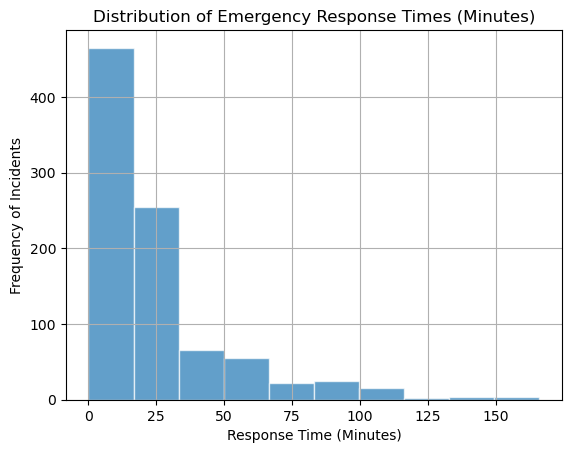

In [85]:
# --- 1. Create the plot using Pandas ---
california_df['RESPONSE_MINUTES'].hist(bins=10, edgecolor='white', alpha=0.7)

# --- 2. Add Labels and Title using Matplotlib ---
plt.title('Distribution of Emergency Response Times (Minutes)')
plt.xlabel('Response Time (Minutes)')
plt.ylabel('Frequency of Incidents')

# --- 3. Display the plot ---
plt.show()

In [86]:
california_df["LATITUDE"] = california_df["LATITUDE"].astype(float)
california_df["LONGITUD"] = california_df["LONGITUD"].astype(float)

In [87]:
# 1. Filter out zero/negative values for log math (safety check)
# We use a small epsilon (1e-6) if there's a true 0, but usually response time > 0.
valid_times = california_df['RESPONSE_MINUTES'][california_df['RESPONSE_MINUTES'] > 0]
min_val = valid_times.min()
max_val = valid_times.max()

# 2. Create Logarithmic Indices
# This creates points that are spaced logarithmically (e.g., 1, 10, 100, 1000)
# Instead of Linear (0, 250, 500, 750, 1000)
log_index = np.geomspace(min_val, max_val, num=5)

# 3. Create the Colormap with these indices
# We use 5 colors to make the transition smoother across the log scale
colormap = cm.LinearColormap(
    colors=['green', 'lightgreen', 'yellow', 'orange', 'red'], 
    index=log_index,
    vmin=min_val, 
    vmax=max_val,
    caption='Response Time (Minutes) - Log Scale'
)

# 4. Create Base Map
map_center = [california_df["LATITUDE"].mean(), california_df["LONGITUD"].mean()]
m = folium.Map(location=map_center, zoom_start=5.5, control_scale=True)

# 5. Iterate and Plot
for _, row in california_df.iterrows():
    response_val = row['RESPONSE_MINUTES']
    
    if pd.isna(response_val) or response_val <= 0:
        c_color = "gray"
    else:
        c_color = colormap(response_val)

    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUD"]],
        radius=5,
        color=c_color,       
        fill=True,
        fill_color=c_color,  
        fill_opacity=0.7,
        popup=f"County: {row.get('COUNTYNAME', 'N/A')}<br>Mins: {response_val:.1f}"
    ).add_to(m)

# 6. Add Legend
m.add_child(colormap)

m

# Clustering by Latitude and Longitude to find distinct geographic regions

In [88]:
from sklearn.cluster import KMeans
import numpy as np

# Extract just the coordinates
X = california_df[["LATITUDE", "LONGITUD"]]

In [89]:
# 1. Initialize the model (n_clusters is the number of groups you want)
kmeans = KMeans(n_clusters=15, random_state=42)

# 2. Fit the model and predict the cluster for each point
# This adds a number (0, 1, 2, 3, 4) to each row
california_df["CLUSTER"] = kmeans.fit_predict(X)

# Check the results
print(california_df["CLUSTER"].value_counts())

CLUSTER
1     123
13    118
10    101
6     101
8      96
5      73
4      69
0      57
9      42
2      36
7      32
12     20
11     19
14     15
3      10
Name: count, dtype: int64


C:\Users\Clayg\miniconda3\envs\mlproj\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [90]:
cluster_colors = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'purple',
    4: 'orange',
    5: 'darkred',
    6: 'darkblue',
    7: 'darkgreen',
    8: 'cadetblue',
    9: 'pink',
    10: 'lightblue',
    11: 'lightgreen',
    12: 'gray',
    13: 'black',
    14: 'teal'
}
map_center = [california_df["LATITUDE"].mean(), california_df["LONGITUD"].mean()]
m = folium.Map(location=map_center, zoom_start=6) # Zoom out to see all clusters

for _, row in california_df.iterrows():
    
    # Get the cluster ID
    cluster_id = row["CLUSTER"]
    
    # Map ID to color (default to black if something goes wrong)
    c_color = cluster_colors.get(cluster_id, "black")
    
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUD"]],
        radius=5,
        color=c_color,
        fill=True,
        fill_color=c_color,
        fill_opacity=0.7,
        popup=f"Cluster: {cluster_id}"
    ).add_to(m)

m

**Cluster Analysis**

In [91]:
cluster_mean_response_times = california_df.groupby("CLUSTER")["RESPONSE_MINUTES"].mean()
cluster_std_response_times = california_df.groupby("CLUSTER")["RESPONSE_MINUTES"].std()
cluster_count_response_times = california_df['CLUSTER'].value_counts()
cluster_stats = california_df.groupby("CLUSTER")["RESPONSE_MINUTES"].agg(
    Mean_Response_Minutes='mean',
    Std_Dev_Response_Minutes='std',
    Cluster_Size='count'
)
cluster_stats

,Mean_Response_Minutes,Std_Dev_Response_Minutes,Cluster_Size
CLUSTER,,,
0,24.280702,22.863535,57
1,31.796748,32.950524,123
2,24.500000,15.481787,36
3,22.200000,15.353610,10
4,23.434783,21.772540,69
5,20.863014,20.354030,73
6,25.722772,27.609100,101
7,26.156250,21.737598,32
8,21.562500,25.705544,96


**Reflection:** The standard deviations are nearly equal to the means across the clusters, and the means of the clusters don't change very much. It seems very unlikely that these clusters will lend any predictive power to the model. 

## Preparing the dataframe for modeling:

First we will seperate the target feature from the predictive features

In [55]:
X_cols = ['RUR_URB', 'DAY_WEEK', 'HOUR', 'FUNC_SYS', 'WEATHER']
y_cols = california_df['RESPONSE_MINUTES']

#Take a look at the distributions for each feature to understand how to bin them
for col in X_cols:
    x=california_df[col].value_counts().sort_index()
    print(x)

RUR_URB
1    277
2    635
Name: count, dtype: int64
DAY_WEEK
1    162
2     95
3    113
4     95
5    111
6    158
7    178
Name: count, dtype: int64
HOUR
0     49
1     38
2     37
3     34
4     35
5     35
6     34
7     16
8     27
9     25
10    21
11    24
12    24
13    23
14    33
15    32
16    34
17    64
18    52
19    54
20    52
21    66
22    54
23    49
Name: count, dtype: int64
FUNC_SYS
1    176
2    103
3    234
4    197
5    120
6     14
7     68
Name: count, dtype: int64
WEATHER
1     792
2      30
5      10
6       3
7       1
10     75
12      1
Name: count, dtype: int64


In [56]:
#Create maps to consolidate the feature values, leading to less sparse data and fewer dimensions
#Weather will be reduced to 4 features: 1 = clear, 2 = rain, 3 = wind/low visibility, 4 = cloudy 
weather_map = {12:2, 5:3, 6:3, 7:3, 10:4}

#Hour is broken down into 4 six-hour segments
hour_map = {0:1,2:1,3:1,4:1,5:1,6:2,7:2,8:2,9:2,10:2,11:2, 12:3, 13:3, 14:3, 15:3, 16:3, 17:3, 18:4, 19:4, 20:4, 21:4, 22:4, 23:4}

california_df['WEATHER'] = california_df['WEATHER'].replace(weather_map)
california_df["HOUR"] = california_df['HOUR'].replace(hour_map)

In [57]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [58]:
#Create our training and testing sets

X_train, X_test, y_train, y_test = train_test_split(california_df[X_cols], y_cols, test_size=0.2, random_state=42)

## Random Forest Regressor

I predict that a Random Forest regressor will be effective at prediction because its bagging and boostrapping approach effectively lowers the influence of individual outliers. Because this dataset is 

In [60]:
#Apply one-hot encoding to our features
preprocessor = ColumnTransformer(
    transformers=[     
        ('cat', OneHotEncoder(handle_unknown='ignore'), X_cols) 
    ],
    remainder='passthrough'
)

#Create a RandomForestRegressor pipeline
pipeline_RF = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])


#Tune model paremeters using Grid Search to find the best combination of parameters
param_grid_RF = {
    'regressor__n_estimators': range(50, 151, 10),  # 50 to 150, step 10
    'regressor__min_samples_split': range(15, 26),  
    'regressor__max_features': range(10, 20)         
}


grid_search_RF = GridSearchCV(
    estimator=pipeline_RF,
    param_grid=param_grid_RF,
    cv=5,                             
    scoring='neg_mean_squared_error', 
    n_jobs=-1,                        
    verbose=1
)

grid_search_RF.fit(X_train, y_train)
print(f"Best Parameters: {grid_search_RF.best_params_}")

Fitting 5 folds for each of 1210 candidates, totalling 6050 fits
Best Parameters: {'regressor__max_features': 12, 'regressor__min_samples_split': 25, 'regressor__n_estimators': 50}


In [61]:
best_rmse = np.sqrt(-1 * grid_search_RF.best_score_)
print(f"Best Cross-Validation RMSE: {best_rmse:.2f} minutes")

Best Cross-Validation RMSE: 25.36 minutes


In [62]:
y_mean = np.mean(y_test)
print(y_mean)

25.814207650273225


**Reflection**: Even after tuning our parameters, we still have an RMSE which is almost equal to the mean of the prediction values. This means that the model is as good at predicting the values as if it were a random guess. 

# Gradient Boosting Regressor

In [64]:
from sklearn.ensemble import GradientBoostingRegressor

pipeline_GB = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(learning_rate = .1, n_estimators = 500))
])

param_grid_GB = {
    'regressor__max_depth': range(2, 40, 2),  # 2 to 20, step 2
    'regressor__min_samples_split': range(19, 40, 2),    # 2 to 10       
}

grid_search_GB = GridSearchCV(
    estimator=pipeline_GB,
    param_grid=param_grid_GB,
    cv=5,                             
    scoring='neg_mean_squared_error', 
    n_jobs=-1,                        
    verbose=1
)

grid_search_GB.fit(X_train, y_train)
print(f"Best Parameters: {grid_search_GB.best_params_}")

Fitting 5 folds for each of 209 candidates, totalling 1045 fits
Best Parameters: {'regressor__max_depth': 2, 'regressor__min_samples_split': 25}


In [65]:
best_rmse_GB = np.sqrt(-1 * grid_search_GB.best_score_)
print(f"Best Cross-Validation RMSE: {best_rmse_GB:.2f} minutes")

Best Cross-Validation RMSE: 26.02 minutes


In [67]:
y_mean = np.mean(y_test)
print(y_mean)

25.814207650273225


Both Random Forest and Gradient Boosted regressors have effectively failed to find any meaningful signal in the data. The RMSE is effectively even to the mean, making it about as good at prediction as a random guess.

My disappointment is immeasurable, and my day is ruined. 

What this does tell us: Ambulance times are not meaningfully correlated to any of the selected features. Considering these features include geography, time and weather, if these don't correspond to ambulance arrival times I don't know what would.  